## 5.1 회귀 소개

### 1. 회귀계수란?

회귀계수는 쉽게 말해 **"X가 1 늘어날 때 y가 얼마나 바뀌는가"** 를 나타내는 숫자다.


- 회귀계수가 **양수** → X가 증가하면 y도 증가
- 회귀계수가 **음수** → X가 증가하면 y는 감소
- 숫자가 **클수록** 그 변수의 영향력이 크다는 뜻

절편은 X가 0일 때의 y 값이라고 보면 된다.  
sklearn에서는 `model.coef_`로 회귀계수, `model.intercept_`로 절편을 확인할 수 있다.

---

### 2. 선형 회귀 vs 비선형 회귀

**선형 회귀** : X와 y의 관계가 **직선**으로 표현되는 경우  
**비선형 회귀** : X와 y의 관계가 **곡선**인 경우


참고로 다항 회귀(x², x³ 사용)는 곡선처럼 보이지만, 수학적으로는 선형 회귀로 분류된다.

---

### 3. 단순 회귀 vs 다중 회귀

**단순 회귀** : 입력 변수가 **1개**인 경우  
**다중 회귀** : 입력 변수가 **2개 이상**인 경우

실제 데이터는 영향을 주는 변수가 여러 개인 경우가 많아서 다중 회귀를 더 자주 쓴다.

---

### 4. 회귀 모델의 종류

### 일반 선형 회귀

가장 기본적인 회귀 방법으로, 예측값과 실제값의 **차이(오차)를 최소화**하는 방향으로 계수를 구한다.  
규제가 없어서 변수가 많아지면 과적합이 생길 수 있다.

```

---
### 릿지 회귀 (Ridge)

일반 선형 회귀에 **"계수가 너무 커지지 않도록"** 브레이크를 거는 방법이다.  
계수들을 전부 0에 가깝게 줄여주지만, 완전히 0이 되지는 않는다.  
→ 변수를 모두 살리면서 과적합만 줄이고 싶을 때 사용


```

---

### 라쏘 회귀 (Lasso)

릿지와 비슷하지만, **중요하지 않은 변수의 계수를 아예 0으로** 만들어버린다.  
→ 자동으로 필요 없는 변수를 제거해주는 효과  
→ 변수가 많고 그 중 일부만 중요할 때 유용



---

### 엘라스틱넷 (ElasticNet)

릿지와 라쏘를 **반반 섞은** 방법이다.  
둘 중 어느 게 더 나을지 모를 때, 또는 변수 간 상관관계가 높을 때 사용한다.



---

### 로지스틱 회귀 (Logistic Regression)

이름은 "회귀"지만 사실 **분류** 문제에 쓰는 모델이다.  
결과를 0~1 사이의 **확률**로 변환해서, 특정 기준(보통 0.5)을 넘으면 1, 아니면 0으로 분류한다.



# 단순 선형 회귀로 회귀 이해하기

---

## 1. 단순 선형 회귀란?

독립변수(x)가 딱 1개이고, x와 y의 관계가 직선이라고 가정하는 가장 기본적인 회귀 모델이다.

```
y = w0 + w1 * x
```

그런데 어떤 직선이 "가장 잘 맞는" 직선일까?
→ 이걸 판단하기 위해 **RSS**와 **MSE**가 필요하다.

---

## 2. 잔차 (Residual) — 얼마나 틀렸는지

모델이 예측한 값과 실제 값의 차이를 **잔차**라고 한다.

```
잔차 = 실제값 - 예측값
```


잔차가 0에 가까울수록 예측이 정확하다는 뜻이다.

---

## 3. RSS — 잔차를 하나의 숫자로

각 데이터마다 잔차가 생기는데, 이걸 하나로 합쳐서 모델이 전체적으로 얼마나 틀렸는지 보고 싶다.

그냥 다 더하면 문제가 생긴다.
잔차가 +5, -5처럼 양수/음수가 섞이면 서로 상쇄돼서 0이 나올 수 있기 때문이다.

그래서 **잔차를 제곱해서 다 더한다.**

```
RSS = (잔차1)² + (잔차2)² + (잔차3)² + ...
```

이게 **RSS (Residual Sum of Squares), 잔차 제곱합**이다.

RSS가 작을수록 → 예측이 정확한 모델!

선형 회귀의 목표는 이 **RSS를 최소로 만드는 w0, w1을 찾는 것**이다.

---

## 4. MSE — 데이터 수에 상관없이 비교하려면

RSS는 데이터가 많을수록 자연히 커진다.
데이터 100개짜리 모델과 1000개짜리 모델의 RSS를 그냥 비교하면 공평하지 않다.

그래서 RSS를 데이터 수로 나눠준 것이 **MSE**다.

```
MSE = RSS / 데이터 수
```

MSE는 **Mean Squared Error, 평균 제곱 오차**이다.
평균을 내기 때문에 데이터 수가 달라도 모델끼리 비교할 수 있다.

---

## 5. RMSE — 단위를 맞추려면

MSE는 잔차를 제곱했기 때문에 단위도 제곱이 된다.
예를 들어 점수(점)를 예측했다면 MSE의 단위는 점²이 된다.

원래 단위로 되돌리고 싶을 때 루트를 씌운 것이 **RMSE**다.

```
RMSE = √MSE
```

RMSE는 **Root Mean Squared Error**이고, 실제 y와 단위가 같아서 해석이 직관적이다.

## 5.3 Gradient Descent

**실제값을 Y=4X+6 시뮬레이션하는 데이터 값 생성**

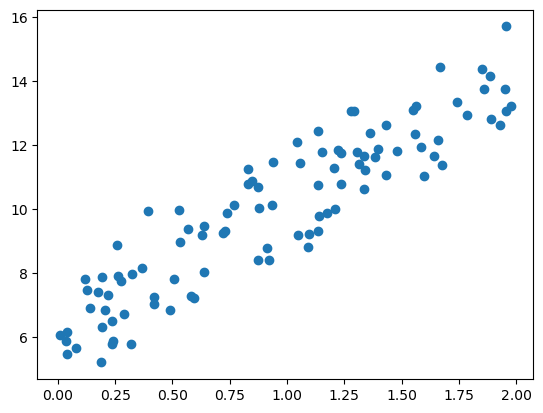

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# 재현성을 위해 랜덤 시드 고정 (seed가 같으면 항상 같은 난수가 나옴)
np.random.seed(0)

# y = 4X + 6 에 노이즈를 추가한 가상의 데이터 100개 생성
# np.random.rand(100,1) → 0~2 사이의 값 100개, X로 사용
X = 2 * np.random.rand(100,1)
# np.random.randn(100,1) → 평균 0, 표준편차 1의 노이즈 추가
y = 6 + 4 * X + np.random.randn(100,1)

# X(공부시간)와 y(점수)의 관계를 산점도로 시각화
plt.scatter(X, y)


In [3]:
# X와 y의 배열 모양 확인 → (100, 1) 이어야 LinearRegression 입력으로 사용 가능
X.shape, y.shape


((100, 1), (100, 1))

**w0과 w1의 값을 최소화 할 수 있도록 업데이트 수행하는 함수 생성**

* 예측 배열 y_pred는 np.dot(X, w1.T) + w0 임
100개의 데이터 X(1,2,...,100)이 있다면 예측값은 w0 + X(1)*w1 + X(2)*w1 +..+ X(100)*w1이며, 이는 입력 배열 X와 w1 배열의 내적임.
* 새로운 w1과 w0를 update함
![](./image01.png)

In [4]:
# w1(기울기)과 w0(절편)을 얼마나 업데이트할지 계산하는 함수
def get_weight_updates(w1, w0, X, y, learning_rate=0.01):
    N = len(y)
    # 업데이트량을 담을 배열을 0으로 초기화 (w1, w0와 같은 shape)
    w1_update = np.zeros_like(w1)
    w0_update = np.zeros_like(w0)

    # 현재 w1, w0로 예측값 계산 → y_pred = X·w1 + w0
    y_pred = np.dot(X, w1.T) + w0
    # 잔차 계산 (실제값 - 예측값)
    diff = y - y_pred

    # w0 업데이트에 필요한 행렬 (모두 1로 구성, 내적 연산용)
    w0_factors = np.ones((N, 1))

    # MSE를 w1으로 편미분한 값 → 기울기 업데이트량 계산
    w1_update = -(2/N) * learning_rate * (np.dot(X.T, diff))
    # MSE를 w0으로 편미분한 값 → 절편 업데이트량 계산
    w0_update = -(2/N) * learning_rate * (np.dot(w0_factors.T, diff))

    return w1_update, w0_update


In [5]:
# get_weight_updates() 함수 내부 로직을 직접 풀어서 계산한 검증 코드
# w0, w1을 모두 0으로 초기화
w0 = np.zeros((1,1))
w1 = np.zeros((1,1))

# 예측값과 잔차 계산
y_pred = np.dot(X, w1.T) + w0
diff = y - y_pred
print(diff.shape)  # (100, 1)이어야 함

# w0 업데이트에 사용할 1로 채워진 배열 생성
w0_factors = np.ones((100,1))

# w1, w0 업데이트량 직접 계산 (함수 내부와 동일한 로직)
w1_update = -(2/100) * 0.01 * (np.dot(X.T, diff))
w0_update = -(2/100) * 0.01 * (np.dot(w0_factors.T, diff))
print(w1_update.shape, w0_update.shape)  # 각각 (1,1) 이어야 함
w1, w0  # 아직 0인 상태 확인


(100, 1)
(1, 1) (1, 1)


(array([[0.]]), array([[0.]]))

**반복적으로 경사 하강법을 이용하여 get_weigth_updates()를 호출하여 w1과 w0를 업데이트 하는 함수 생성**

In [6]:
# iters 횟수만큼 반복해서 w1, w0를 조금씩 업데이트하는 경사 하강법 함수
def gradient_descent_steps(X, y, iters=10000):
    # w0, w1을 0으로 초기화하고 시작
    w0 = np.zeros((1,1))
    w1 = np.zeros((1,1))

    # iters 횟수만큼 반복 → 매 반복마다 w1, w0를 업데이트량만큼 조정
    for ind in range(iters):
        w1_update, w0_update = get_weight_updates(w1, w0, X, y, learning_rate=0.01)
        # 업데이트량을 빼줌 (경사 반대 방향으로 이동)
        w1 = w1 - w1_update
        w0 = w0 - w0_update

    return w1, w0


**예측 오차 비용을 계산을 수행하는 함수 생성 및 경사 하강법 수행**

In [7]:
# MSE(평균 제곱 오차)를 계산하는 비용함수 정의
def get_cost(y, y_pred):
    N = len(y)
    # (실제값 - 예측값)² 의 평균
    cost = np.sum(np.square(y - y_pred)) / N
    return cost

# 경사 하강법 1000번 반복 → 최적 w1, w0 탐색
w1, w0 = gradient_descent_steps(X, y, iters=1000)
print("w1:{0:.3f} w0:{1:.3f}".format(w1[0,0], w0[0,0]))  # w1≈4, w0≈6에 수렴하면 성공

# 최적 w1, w0로 예측값 계산
y_pred = w1[0,0] * X + w0
# 최종 MSE 출력 → 값이 작을수록 예측이 정확함
print('Gradient Descent Total Cost:{0:.4f}'.format(get_cost(y, y_pred)))


w1:4.022 w0:6.162
Gradient Descent Total Cost:0.9935


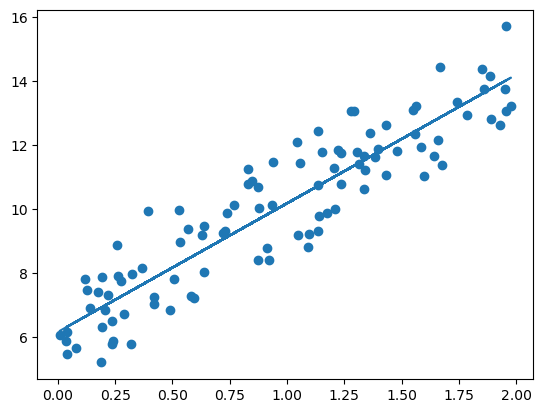

In [8]:
# 원본 데이터(점)와 학습된 회귀 직선을 함께 시각화
plt.scatter(X, y)       # 실제 데이터 산점도
plt.plot(X, y_pred)     # 학습된 회귀 직선


**미니 배치 확률적 경사 하강법을 이용한 최적 비용함수 도출**

In [9]:
# 전체 데이터가 아닌 일부(batch_size개)만 랜덤으로 뽑아서 업데이트하는 확률적 경사 하강법(SGD)
def stochastic_gradient_descent_steps(X, y, batch_size=10, iters=1000):
    w0 = np.zeros((1,1))
    w1 = np.zeros((1,1))
    prev_cost = 100000
    iter_index = 0

    for ind in range(iters):
        np.random.seed(ind)
        # 전체 데이터에서 랜덤하게 섞은 인덱스 생성 (비복원 추출)
        stochastic_random_index = np.random.permutation(X.shape[0])
        # 앞에서 batch_size개만 뽑아서 미니배치 구성
        sample_X = X[stochastic_random_index[0:batch_size]]
        sample_y = y[stochastic_random_index[0:batch_size]]
        # 미니배치로만 업데이트량 계산 → 전체 GD보다 빠르고 노이즈가 많음
        w1_update, w0_update = get_weight_updates(w1, w0, sample_X, sample_y, learning_rate=0.01)
        w1 = w1 - w1_update
        w0 = w0 - w0_update

    return w1, w0


In [10]:
# SGD 1000번 반복 후 최적 w1, w0 출력
w1, w0 = stochastic_gradient_descent_steps(X, y, iters=1000)
print("w1:", round(w1[0,0],3), "w0:", round(w0[0,0],3))

# SGD로 구한 w1, w0로 예측값 계산
y_pred = w1[0,0] * X + w0
# SGD의 최종 MSE 출력 → GD와 비슷한 값이 나오면 정상
print('Stochastic Gradient Descent Total Cost:{0:.4f}'.format(get_cost(y, y_pred)))


w1: 4.028 w0: 6.156
Stochastic Gradient Descent Total Cost:0.9937


## 5.4 사이킷런 LinearRegression을 이용한 보스턴 주택 가격 예측

ImportError: 
`load_boston` has been removed from scikit-learn since version 1.2.로 인해서 캘리포니아 주택 데이터로 대체

코드는 다 써놓으나 연습은 캘리포니아 주택 데이터 이용

In [15]:
# [참고용 - 실행 불가] sklearn LinearRegression 클래스 파라미터 목록
# fit_intercept: 절편 학습 여부 / normalize: 정규화 여부 / n_jobs: 병렬 처리 수
class sklearn.linear_model.LinearRegression(fit_intercept=True, normalize=False, copy_X=True, n_jobs=1)


SyntaxError: invalid syntax (3913729302.py, line 1)

In [ ]:
# sklearn의 LinearRegression 모델 객체 생성
# fit_intercept=True → 절편(w0) 포함해서 학습
# copy_X=True → 원본 X 데이터 변경 방지
from sklearn.linear_model import LinearRegression

model = LinearRegression(fit_intercept=True, copy_X=True, n_jobs=1)


In [ ]:
# [에러 셀 - 실행 불가] 보스턴 데이터셋은 sklearn 1.2부터 삭제됨
# 아래 셀(캘리포니아 데이터)로 대체해서 사용
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.datasets import load_boston
import warnings
warnings.filterwarnings('ignore')  # sklearn 버전 관련 경고 메시지 숨김
%matplotlib inline

# boston 데이타셋 로드
boston = load_boston()

# boston 데이타셋 DataFrame 변환 
bostonDF = pd.DataFrame(boston.data, columns=boston.feature_names)

# boston dataset의 target array는 주택 가격임. 이를 PRICE 컬럼으로 DataFrame에 추가함. 
bostonDF['PRICE'] = boston.target
print('Boston 데이타셋 크기 :', bostonDF.shape)
bostonDF.head()


ImportError: 
`load_boston` has been removed from scikit-learn since version 1.2.

The Boston housing prices dataset has an ethical problem: as
investigated in [1], the authors of this dataset engineered a
non-invertible variable "B" assuming that racial self-segregation had a
positive impact on house prices [2]. Furthermore the goal of the
research that led to the creation of this dataset was to study the
impact of air quality but it did not give adequate demonstration of the
validity of this assumption.

The scikit-learn maintainers therefore strongly discourage the use of
this dataset unless the purpose of the code is to study and educate
about ethical issues in data science and machine learning.

In this special case, you can fetch the dataset from the original
source::

    import pandas as pd
    import numpy as np

    data_url = "http://lib.stat.cmu.edu/datasets/boston"
    raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
    data = np.hstack([raw_df.values[:

In [16]:
# 보스턴 대신 캘리포니아 주택 데이터 사용 (sklearn 1.2 이상 호환)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.datasets import fetch_california_housing
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# 캘리포니아 주택 데이터셋 로드 (8개 피처, 타겟은 주택 중앙값)
california = fetch_california_housing()

# DataFrame으로 변환 (이후 코드와의 호환성을 위해 변수명은 bostonDF 유지)
bostonDF = pd.DataFrame(california.data, columns=california.feature_names)

# 타겟(주택 가격)을 PRICE 컬럼으로 추가
bostonDF['PRICE'] = california.target
print('California 데이타셋 크기 :', bostonDF.shape)
bostonDF.head()  # 상위 5개 행 출력


California 데이타셋 크기 : (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


* CRIM: 지역별 범죄 발생률  
* ZN: 25,000평방피트를 초과하는 거주 지역의 비율
* NDUS: 비상업 지역 넓이 비율
* CHAS: 찰스강에 대한 더미 변수(강의 경계에 위치한 경우는 1, 아니면 0)
* NOX: 일산화질소 농도
* RM: 거주할 수 있는 방 개수
* AGE: 1940년 이전에 건축된 소유 주택의 비율
* DIS: 5개 주요 고용센터까지의 가중 거리
* RAD: 고속도로 접근 용이도
* TAX: 10,000달러당 재산세율
* PTRATIO: 지역의 교사와 학생 수 비율
* B: 지역의 흑인 거주 비율
* LSTAT: 하위 계층의 비율
* MEDV: 본인 소유의 주택 가격(중앙값)

* 각 컬럼별로 주택가격에 미치는 영향도를 조사

In [18]:
# DataFrame의 컬럼명 목록 출력 → 이후 regplot, 회귀 학습에 사용할 피처명 확인
print(bostonDF.columns.tolist())


['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'PRICE']


KeyError: 'RM'

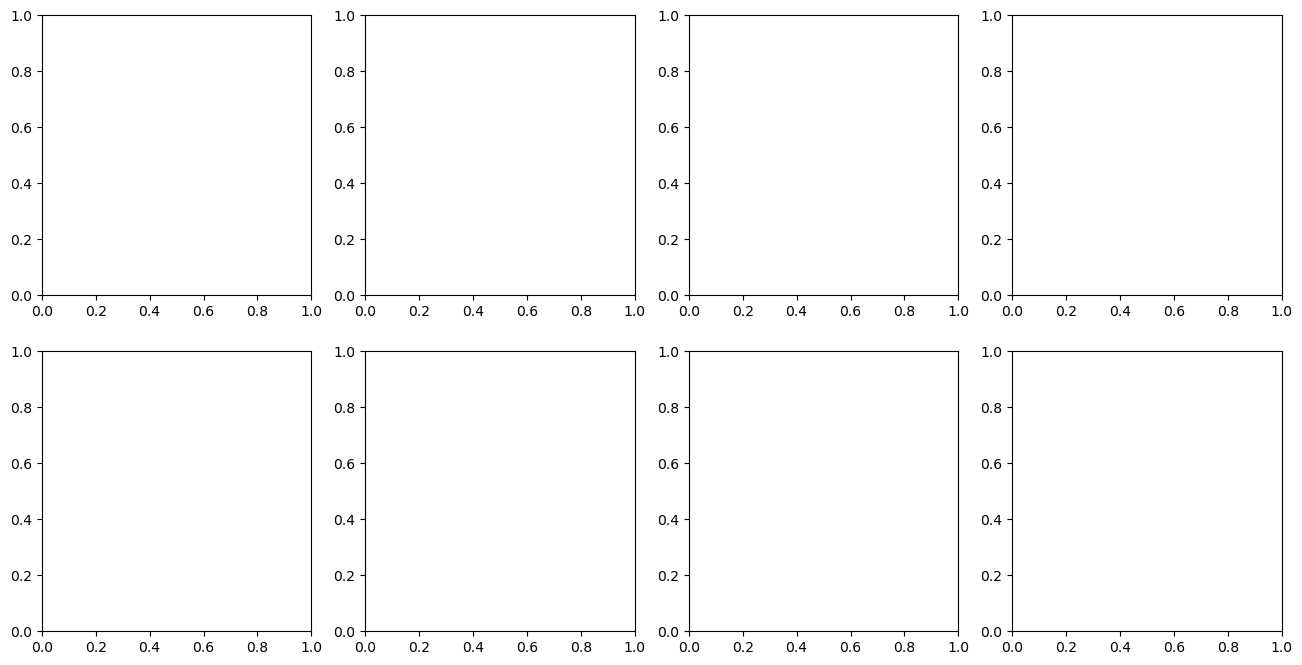

In [20]:
# [에러 셀 - 실행 불가] 보스턴 피처명('RM','ZN' 등) 사용 → 캘리포니아 데이터에 없어 KeyError 발생
# 아래 셀(cell 28)에서 캘리포니아 피처명으로 수정해서 실행

# 2행 4열 서브플롯 구성 (8개 피처 동시에 비교)
fig, axs = plt.subplots(figsize=(16,8), ncols=4, nrows=2)
lm_features = ['RM','ZN','INDUS','NOX','AGE','PTRATIO','LSTAT','RAD']
for i, feature in enumerate(lm_features):
    row = int(i/4)
    col = i%4
    # regplot: 산점도 + 선형 회귀선을 함께 그려줌
    sns.regplot(x=feature, y='PRICE', data=bostonDF, ax=axs[row][col])

fig1 = plt.gcf()
# 고해상도(300dpi) tif 파일로 저장
fig1.savefig('p322_boston.tif', format='tif', dpi=300, bbox_inches='tight')


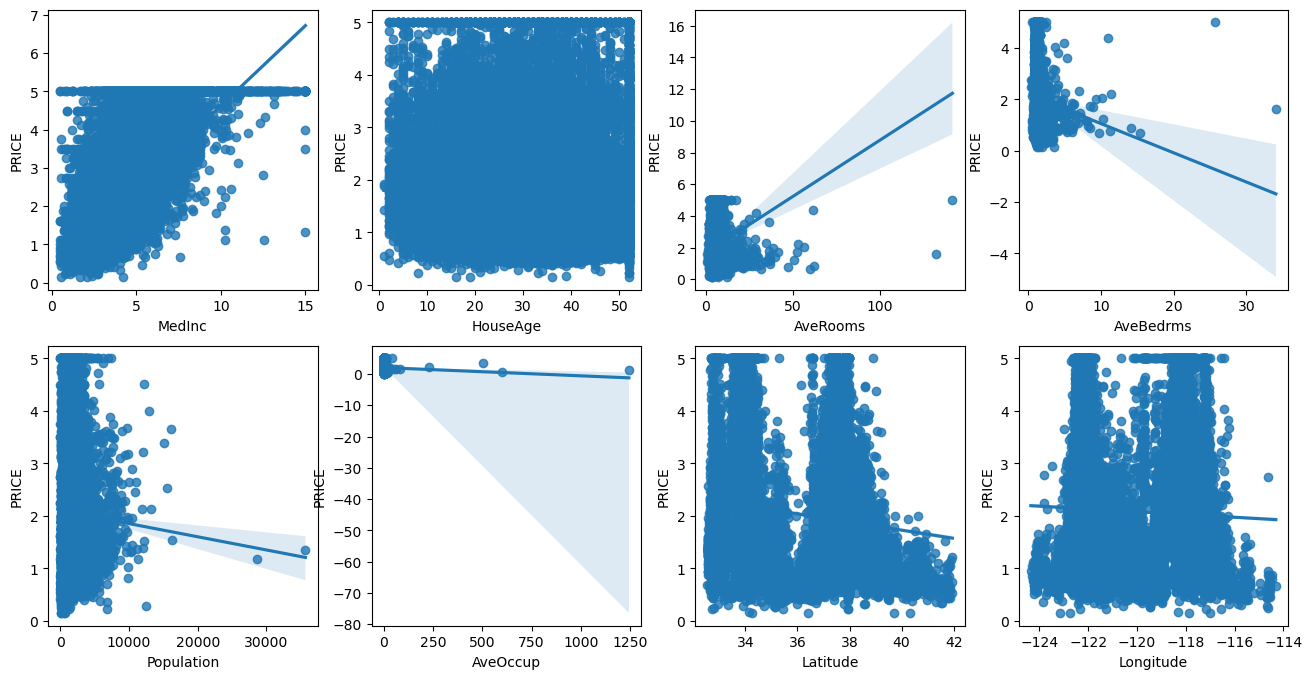

In [ ]:
# 캘리포니아 데이터 피처명으로 수정한 regplot 시각화
fig, axs = plt.subplots(figsize=(16,8), ncols=4, nrows=2)
# bostonDF.columns.tolist()로 확인한 캘리포니아 피처명으로 변경
lm_features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
for i, feature in enumerate(lm_features):
    row = int(i/4)
    col = i%4
    # 각 피처와 주택가격(PRICE)의 관계를 산점도 + 회귀선으로 표시
    sns.regplot(x=feature, y='PRICE', data=bostonDF, ax=axs[row][col])

fig1 = plt.gcf()
# 이미지로 저장
fig1.savefig('p322_california.tif', format='tif', dpi=300, bbox_inches='tight')


**학습과 테스트 데이터 세트로 분리하고 학습/예측/평가 수행**

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 타겟(y)과 피처(X) 분리
y_target = bostonDF['PRICE']
X_data = bostonDF.drop(['PRICE'], axis=1, inplace=False)

# 데이터를 학습(70%)과 테스트(30%)로 분리
X_train, X_test, y_train, y_test = train_test_split(X_data, y_target, test_size=0.3, random_state=156)

# LinearRegression 모델 학습 → 테스트 데이터로 예측
lr = LinearRegression()
lr.fit(X_train, y_train)
y_preds = lr.predict(X_test)

# 평가 지표 계산
mse = mean_squared_error(y_test, y_preds)     # MSE: 평균 제곱 오차
rmse = np.sqrt(mse)                           # RMSE: 단위 맞춘 평균 오차

print('MSE : {0:.3f} , RMSE : {1:.3F}'.format(mse, rmse))
print('Variance score : {0:.3f}'.format(r2_score(y_test, y_preds)))  # R²: 1에 가까울수록 좋음


MSE : 0.543 , RMSE : 0.737
Variance score : 0.595


In [23]:
# 학습된 모델의 절편(w0)과 각 피처별 회귀계수(w1~wn) 출력
print('절편 값:', lr.intercept_)
print('회귀 계수값:', np.round(lr.coef_, 1))  # 소수점 1자리로 반올림해서 출력


절편 값: -37.239053052941735
회귀 계수값: [ 0.4  0.  -0.1  0.6 -0.  -0.  -0.4 -0.4]


In [24]:
# 회귀계수를 큰 값 순으로 정렬해서 어떤 피처가 가격에 가장 영향을 주는지 확인
# pd.Series로 변환 시 index를 피처명으로 지정해야 어떤 피처인지 구분 가능
coeff = pd.Series(data=np.round(lr.coef_, 1), index=X_data.columns)
coeff.sort_values(ascending=False)  # 내림차순 정렬 → 양의 영향력이 큰 피처부터 표시


AveBedrms     0.6
MedInc        0.4
HouseAge      0.0
Population   -0.0
AveOccup     -0.0
AveRooms     -0.1
Latitude     -0.4
Longitude    -0.4
dtype: float64

In [25]:
from sklearn.model_selection import cross_val_score

y_target = bostonDF['PRICE']
X_data = bostonDF.drop(['PRICE'], axis=1, inplace=False)
lr = LinearRegression()

# 5-Fold 교차 검증으로 MSE 계산
# scoring="neg_mean_squared_error" → sklearn은 MSE를 음수로 반환하므로 -1 곱해서 양수로 복원
neg_mse_scores = cross_val_score(lr, X_data, y_target, scoring="neg_mean_squared_error", cv=5)
rmse_scores = np.sqrt(-1 * neg_mse_scores)   # RMSE로 변환
avg_rmse = np.mean(rmse_scores)              # 5개 fold의 평균 RMSE

# 5개 fold 각각의 MSE, RMSE 및 평균 RMSE 출력
print(' 5 folds 의 개별 Negative MSE scores: ', np.round(neg_mse_scores, 2))
print(' 5 folds 의 개별 RMSE scores : ', np.round(rmse_scores, 2))
print(' 5 folds 의 평균 RMSE : {0:.3f} '.format(avg_rmse))


 5 folds 의 개별 Negative MSE scores:  [-0.48 -0.62 -0.65 -0.54 -0.49]
 5 folds 의 개별 RMSE scores :  [0.7  0.79 0.8  0.74 0.7 ]
 5 folds 의 평균 RMSE : 0.746 


## 5-5. Polynomial Regression과 오버피팅/언더피팅 이해
### Polynomial Regression 이해

PolynomialFeatures 클래스로 다항식 변환

![](./image02.png)

In [26]:
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

# 2x2 행렬 생성 → [[0,1],[2,3]]
X = np.arange(4).reshape(2,2)
print('일차 단항식 계수 feature:\n', X)

# PolynomialFeatures(degree=2): 2차 다항식으로 피처 확장
# [x1, x2] → [1, x1, x2, x1², x1*x2, x2²] 총 6개 피처로 늘어남
poly = PolynomialFeatures(degree=2)
poly.fit(X)
poly_ftr = poly.transform(X)
print('변환된 2차 다항식 계수 feature:\n', poly_ftr)


일차 단항식 계수 feature:
 [[0 1]
 [2 3]]
변환된 2차 다항식 계수 feature:
 [[1. 0. 1. 0. 0. 1.]
 [1. 2. 3. 4. 6. 9.]]


3차 다항식 결정값을 구하는 함수 polynomial_func(X) 생성. 즉 회귀식은 결정값 y = 1+ 2x_1 + 3x_1^2 + 4x_2^3 

In [27]:
# 정답 함수 정의: y = 1 + 2x1 + 3x1² + 4x2³
# 이 함수로 만든 y를 타겟으로 삼아, 모델이 계수를 복원할 수 있는지 확인
def polynomial_func(X):
    y = 1 + 2*X[:,0] + 3*X[:,0]**2 + 4*X[:,1]**3
    print(X[:, 0])  # 첫 번째 피처 출력
    print(X[:, 1])  # 두 번째 피처 출력
    return y

# 0~3 값으로 2x2 행렬 생성
X = np.arange(0,4).reshape(2,2)

print('일차 단항식 계수 feature: \n', X)
y = polynomial_func(X)
print('삼차 다항식 결정값: \n', y)


일차 단항식 계수 feature: 
 [[0 1]
 [2 3]]
[0 2]
[1 3]
삼차 다항식 결정값: 
 [  5 125]


3차 다항식 계수의 피처값과 3차 다항식 결정값으로 학습

In [28]:
# 3차 다항식으로 피처 변환 → 2개 피처가 10개로 확장됨
poly_ftr = PolynomialFeatures(degree=3).fit_transform(X)
print('3차 다항식 계수 feature: \n', poly_ftr)

# 확장된 피처로 LinearRegression 학습 → 계수가 정답(1, 2, 3, 4)에 근접하면 성공
model = LinearRegression()
model.fit(poly_ftr, y)
print('Polynomial 회귀 계수\n', np.round(model.coef_, 2))
print('Polynomial 회귀 Shape :', model.coef_.shape)


3차 다항식 계수 feature: 
 [[ 1.  0.  1.  0.  0.  1.  0.  0.  0.  1.]
 [ 1.  2.  3.  4.  6.  9.  8. 12. 18. 27.]]
Polynomial 회귀 계수
 [-0.    0.18  0.18  0.36  0.54  0.72  0.72  1.08  1.62  2.34]
Polynomial 회귀 Shape : (10,)


**사이킷런 파이프라인(Pipeline)을 이용하여 3차 다항회귀 학습**  

사이킷런의 Pipeline 객체는 Feature 엔지니어링 변환과 모델 학습/예측을 순차적으로 결합해줍니다. 

In [29]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import numpy as np

def polynomial_func(X):
    y = 1 + 2*X[:,0] + 3*X[:,0]**2 + 4*X[:,1]**3
    return y

# Pipeline: PolynomialFeatures 변환 → LinearRegression 학습을 한 번에 처리
# 'poly' 단계에서 3차 변환, 'linear' 단계에서 선형 회귀 학습
model = Pipeline([('poly', PolynomialFeatures(degree=3)),
                  ('linear', LinearRegression())])
X = np.arange(4).reshape(2,2)
y = polynomial_func(X)

model = model.fit(X, y)
# named_steps['linear']로 Pipeline 내부의 LinearRegression 계수에 접근
print('Polynomial 회귀 계수\n', np.round(model.named_steps['linear'].coef_, 2))


Polynomial 회귀 계수
 [-0.    0.18  0.18  0.36  0.54  0.72  0.72  1.08  1.62  2.34]


### 다항 회귀를 이용한 과소적합 및 과적합 이해

**cosine 곡선에 약간의 Noise 변동값을 더하여 실제값 곡선을 만듬**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
%matplotlib inline

# 정답 함수: y = cos(1.5π * X) → 비선형 곡선
def true_fun(X):
    return np.cos(1.5 * np.pi * X)
# X는 0부터 1까지 30개의 임의의 값을 순서대로 샘플링한 데이터.
np.random.seed(0)
n_samples = 30
# 0~1 사이의 값 30개를 랜덤 샘플링 후 정렬
X = np.sort(np.random.rand(n_samples))
# 정답 함수값에 약간의 노이즈를 더해 실제 관측값처럼 만듬
y = true_fun(X) + np.random.randn(n_samples) * 0.1


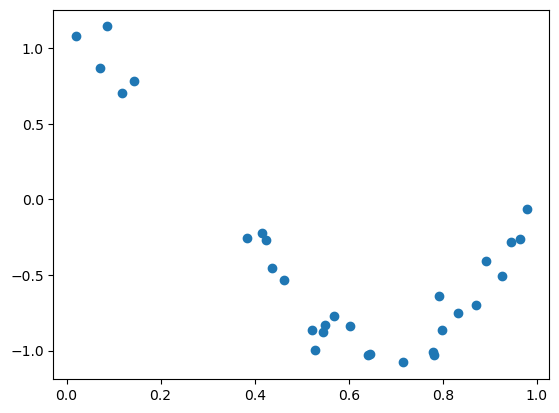

In [31]:
# 생성된 30개 노이즈 데이터의 분포를 산점도로 확인
plt.scatter(X, y)



Degree 1 회귀 계수는 [-1.61] 입니다.
Degree 1 MSE 는 0.40772896250986845 입니다.

Degree 4 회귀 계수는 [  0.47 -17.79  23.59  -7.26] 입니다.
Degree 4 MSE 는 0.04320874987231737 입니다.

Degree 15 회귀 계수는 [-2.98293000e+03  1.03899370e+05 -1.87416114e+06  2.03716252e+07
 -1.44873341e+08  7.09315818e+08 -2.47066009e+09  6.24561742e+09
 -1.15676664e+10  1.56895176e+10 -1.54006289e+10  1.06457467e+10
 -4.91378551e+09  1.35919950e+09 -1.70381195e+08] 입니다.
Degree 15 MSE 는 182618860.9149443 입니다.


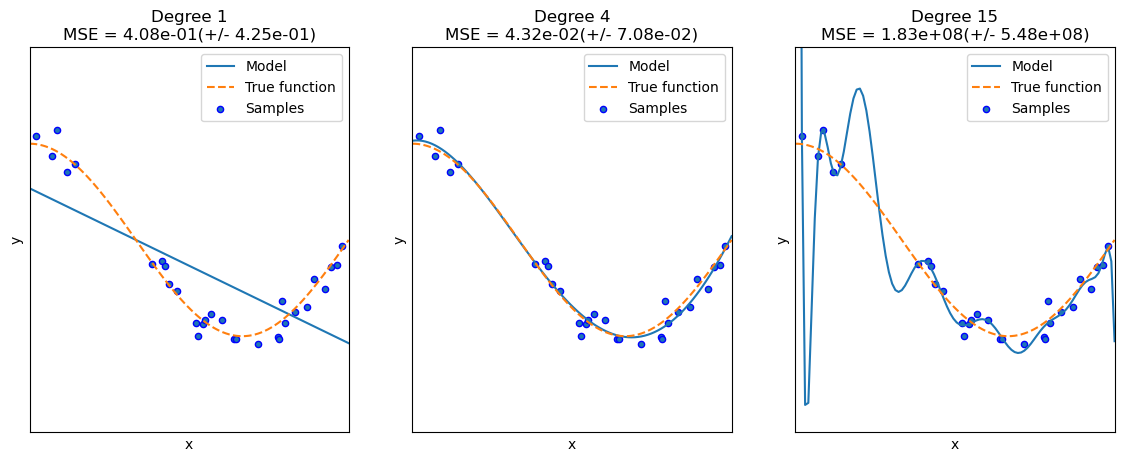

In [ ]:
plt.figure(figsize=(14, 5))
degrees = [1, 4, 15]

# degree를 1(과소적합), 4(적절), 15(과적합)로 바꿔가며 비교
for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())

    # 각 degree로 다항 변환 + 선형 회귀를 Pipeline으로 연결
    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("polynomial_features", polynomial_features),
                         ("linear_regression", linear_regression)])
    pipeline.fit(X.reshape(-1, 1), y)

    # 10-Fold 교차 검증으로 MSE 계산 → degree별 일반화 성능 비교
    scores = cross_val_score(pipeline, X.reshape(-1, 1), y, scoring="neg_mean_squared_error", cv=10)
    # Pipeline 내부의 LinearRegression 계수에 접근
    coefficients = pipeline.named_steps['linear_regression'].coef_
    print('\nDegree {0} 회귀 계수는 {1} 입니다.'.format(degrees[i], np.round(coefficients, 2)))
    print('Degree {0} MSE 는 {1} 입니다.'.format(degrees[i], -1*np.mean(scores)))

    # 0~1 구간을 100개로 나눠 촘촘하게 예측 → 부드러운 곡선으로 표현
    X_test = np.linspace(0, 1, 100)
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model")       # 예측 곡선
    plt.plot(X_test, true_fun(X_test), '--', label="True function")                # 실제 정답 곡선
    plt.scatter(X, y, edgecolor='b', s=20, label="Samples")                       # 학습 데이터
    plt.xlabel("x"); plt.ylabel("y"); plt.xlim((0, 1)); plt.ylim((-2, 2)); plt.legend(loc="best")
    plt.title("Degree {}\nMSE = {:.2e}(+/- {:.2e})".format(degrees[i], -scores.mean(), scores.std()))

plt.show()
